In [3]:

# Import libraries
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load your cleaned dataset (update the file name if different)
df = pd.read_csv('cleaned customer churn dataset.csv')

In [4]:
# Display first few rows
print("🔹 Preview of Dataset:")
print(df.head(), "\n")

🔹 Preview of Dataset:
   CustomerID  Age  Gender  Tenure  Usage Frequency  Support Calls  \
0           1   22  Female      25               14              4   
1           2   41  Female      28               28              7   
2           3   47    Male      27               10              2   
3           4   35    Male       9               12              5   
4           5   53  Female      58               24              9   

   Payment Delay Subscription Type Contract Length  Total Spend  \
0             27             Basic         Monthly          598   
1             13          Standard         Monthly          584   
2             29           Premium          Annual          757   
3             17           Premium       Quarterly          232   
4              2          Standard          Annual          533   

   Last Interaction  Churn  
0                 9      1  
1                20      0  
2                21      0  
3                18      0  
4        

In [5]:
# --- Basic Statistics ---
print("📈 Descriptive Statistics:")
print(df.describe(), "\n")

📈 Descriptive Statistics:
         CustomerID           Age        Tenure  Usage Frequency  \
count  64374.000000  64374.000000  64374.000000     64374.000000   
mean   32187.500000     41.970982     31.994827        15.080234   
std    18583.317451     13.924911     17.098234         8.816470   
min        1.000000     18.000000      1.000000         1.000000   
25%    16094.250000     30.000000     18.000000         7.000000   
50%    32187.500000     42.000000     33.000000        15.000000   
75%    48280.750000     54.000000     47.000000        23.000000   
max    64374.000000     65.000000     60.000000        30.000000   

       Support Calls  Payment Delay   Total Spend  Last Interaction  \
count   64374.000000   64374.000000  64374.000000      64374.000000   
mean        5.400690      17.133952    541.023379         15.498850   
std         3.114005       8.852211    260.874809          8.638436   
min         0.000000       0.000000    100.000000          1.000000   
25%   

In [6]:
# --- Calculate Mean, Median, Mode, Variance ---
print("📊 Summary Stats for Numerical Columns:\n")
numeric_cols = df.select_dtypes(include='number').columns
for col in numeric_cols:
    print(f"{col}:")
    print(f"  Mean     = {df[col].mean():.2f}")
    print(f"  Median   = {df[col].median():.2f}")
    print(f"  Mode     = {df[col].mode()[0]}")
    print(f"  Variance = {df[col].var():.2f}\n")

📊 Summary Stats for Numerical Columns:

CustomerID:
  Mean     = 32187.50
  Median   = 32187.50
  Mode     = 1
  Variance = 345339687.50

Age:
  Mean     = 41.97
  Median   = 42.00
  Mode     = 55
  Variance = 193.90

Tenure:
  Mean     = 31.99
  Median   = 33.00
  Mode     = 46
  Variance = 292.35

Usage Frequency:
  Mean     = 15.08
  Median   = 15.00
  Mode     = 2
  Variance = 77.73

Support Calls:
  Mean     = 5.40
  Median   = 6.00
  Mode     = 9
  Variance = 9.70

Payment Delay:
  Mean     = 17.13
  Median   = 19.00
  Mode     = 22
  Variance = 78.36

Total Spend:
  Mean     = 541.02
  Median   = 534.00
  Mode     = 226
  Variance = 68055.67

Last Interaction:
  Mean     = 15.50
  Median   = 15.00
  Mode     = 7
  Variance = 74.62

Churn:
  Mean     = 0.47
  Median   = 0.00
  Mode     = 0
  Variance = 0.25



In [7]:
# --- Correlation Matrix ---
corr_matrix = df.corr(numeric_only=True)
print("🔹 Correlation Matrix:\n", corr_matrix, "\n")

🔹 Correlation Matrix:
                   CustomerID       Age    Tenure  Usage Frequency  \
CustomerID          1.000000  0.043287  0.103296        -0.062699   
Age                 0.043287  1.000000 -0.007763        -0.038331   
Tenure              0.103296 -0.007763  1.000000         0.023485   
Usage Frequency    -0.062699 -0.038331  0.023485         1.000000   
Support Calls       0.164175  0.005014  0.060065        -0.014072   
Payment Delay       0.290684 -0.016132  0.055963         0.031132   
Total Spend        -0.037068  0.006490  0.009474         0.001527   
Last Interaction   -0.003718 -0.000148  0.005770        -0.009192   
Churn               0.529832  0.063457  0.195327        -0.115098   

                  Support Calls  Payment Delay  Total Spend  Last Interaction  \
CustomerID             0.164175       0.290684    -0.037068         -0.003718   
Age                    0.005014      -0.016132     0.006490         -0.000148   
Tenure                 0.060065       0.055

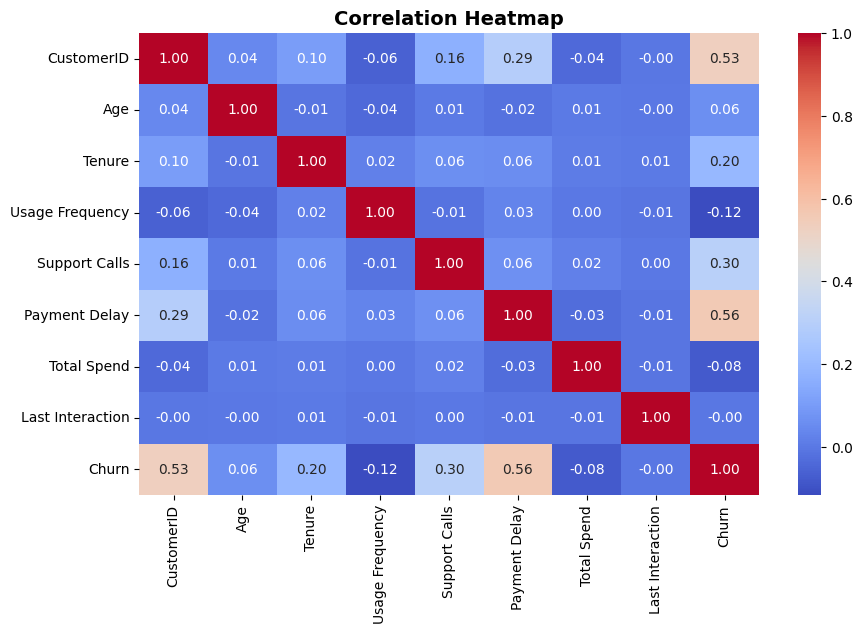

In [8]:
# --- Visualize Correlation with Heatmap ---
plt.figure(figsize=(10,6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap', fontsize=14, fontweight='bold')
plt.show()

In [11]:
# --- Find top 3 correlated features with the target variable (Churn) ---
if 'Churn' in df.columns:
    churn_corr = corr_matrix['Churn'].sort_values(ascending=False)
    print("🔥 Top 3 Features Most Related to Churn:")
    print(churn_corr[1:4])  # excluding Churn itself
else:
    print("⚠️ Column 'Churn' not found — check your column names!")

🔥 Top 3 Features Most Related to Churn:
Payment Delay    0.557386
CustomerID       0.529832
Support Calls    0.304631
Name: Churn, dtype: float64
